In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [51]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [52]:
#get all summary csvs
summary_files = glob.glob('results/**/**/summary.csv', recursive=True)
summary_files = list(set(summary_files))

print(summary_files)

['results/bffcluster/ah1/summary.csv', 'results/bffraw/howitt_b3c2/summary.csv', 'results/hashsolo/cook_mix2/summary.csv', 'results/bffraw/howitt_b3c1/summary.csv', 'results/demuxmixnaive/stoeckius/summary.csv', 'results/hasheddrops/mcginnis_ms/summary.csv', 'results/htodemux/howitt_cell_cap3/summary.csv', 'results/demultiplex2/howitt_b3c1/summary.csv', 'results/hashsolo/mcginnis_hto/summary.csv', 'results/bffcluster/mcginnis_ms/summary.csv', 'results/hashsolo/cook_mix1/summary.csv', 'results/demuxmixnaive/howitt_cell_cap2/summary.csv', 'results/bffcluster/howitt_b1c1/summary.csv', 'results/demultiplex/cook_mix2/summary.csv', 'results/bffcluster/bar18/summary.csv', 'results/hasheddrops/winkler_pdx1b/summary.csv', 'results/bffraw/howitt_b2c1/summary.csv', 'results/bffraw/winkler_pdx1b/summary.csv', 'results/bffcluster/cook_mix3b/summary.csv', 'results/demuxmixnaive/howitt_b3c1/summary.csv', 'results/demultiplex2/winkler_pdx3b/summary.csv', 'results/hashsolo/gaublomme/summary.csv', 'resu

In [53]:
#read and combine
all_results = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

#save combined dataframe
all_results.to_csv('results/all_results.csv', index=False)

all_results

,classification,n,dataset,method
0,doublet,1065,ah1,bff_cluster
1,negative,14,ah1,bff_cluster
2,singlet,4643,ah1,bff_cluster
3,total,5722,ah1,bff_cluster
4,doublet,3323,howitt_b3c2,bff_raw
...,...,...,...,...
843,total,13318,cook_mix3a,hashsolo
844,doublet,5049,howitt_b2c2,demultiplex
845,negative,7205,howitt_b2c2,demultiplex
846,singlet,12552,howitt_b2c2,demultiplex


In [54]:
errors_file = 'results/errors.csv'
if os.path.exists(errors_file):
    errors = pd.read_csv(errors_file)
else:
    errors = pd.DataFrame(columns=['dataset', 'method', 'error'])

errors.head()

,dataset,method,error
0,winkler_pdx3a,gmm_demux,Does not finish - EM algorithm gets stuck duri...
1,winkler_pdx3b,gmm_demux,Does not finish - EM algorithm gets stuck duri...
2,winkler_pdx1a,htodemux,clara clustering creates clusters with zero co...
3,winkler_pdx1b,htodemux,clara clustering creates clusters with zero co...
4,winkler_pdx1c,htodemux,clara clustering creates clusters with zero co...


In [55]:
plot_data = all_results[all_results['classification'] != 'total'].copy()
datasets = sorted(plot_data['dataset'].unique())

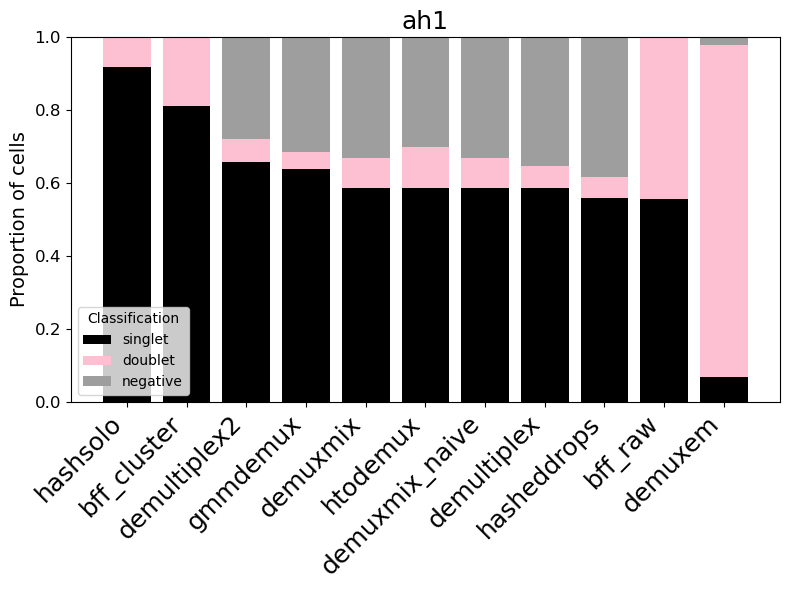

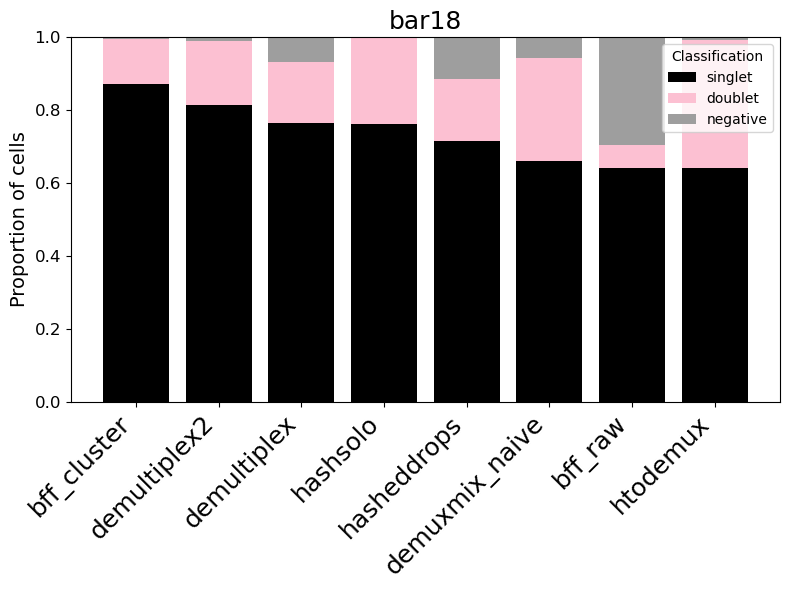

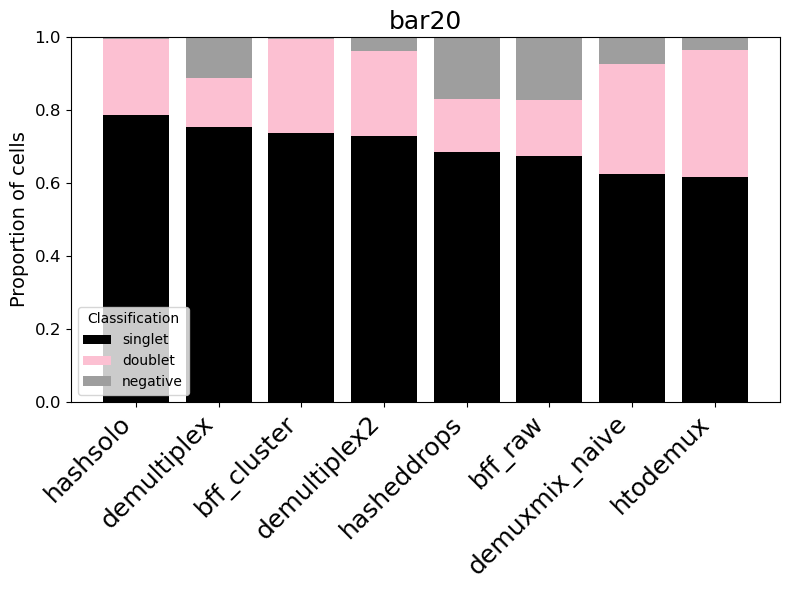

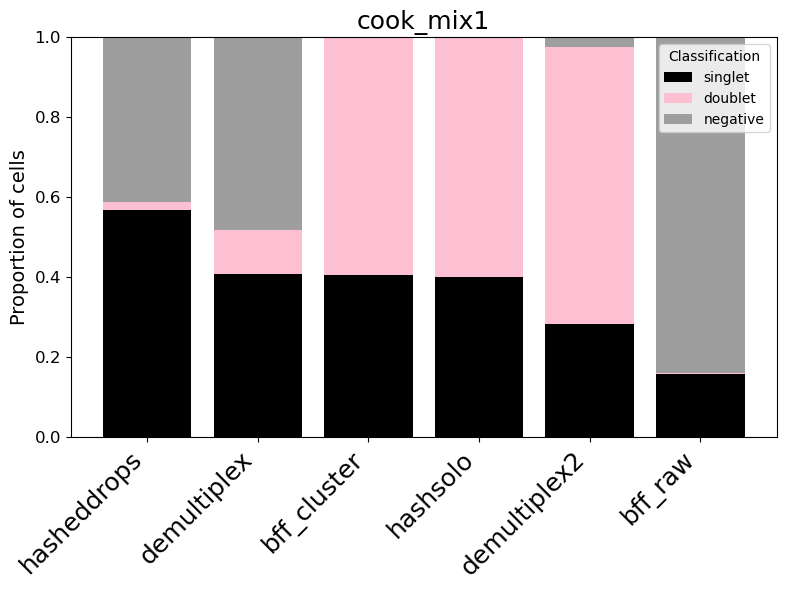

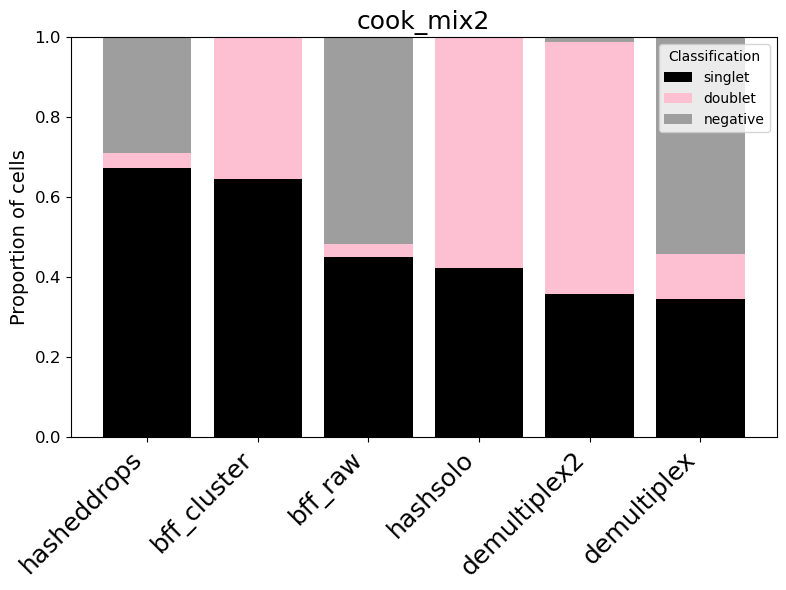

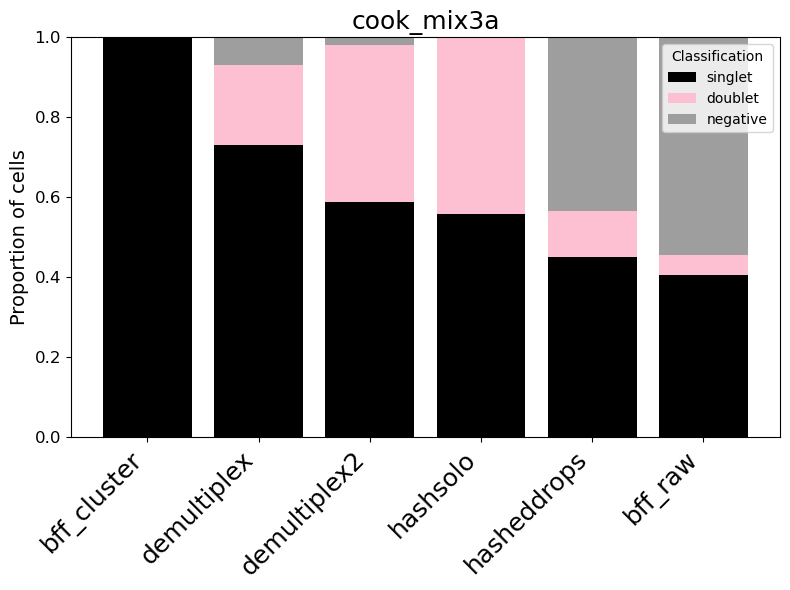

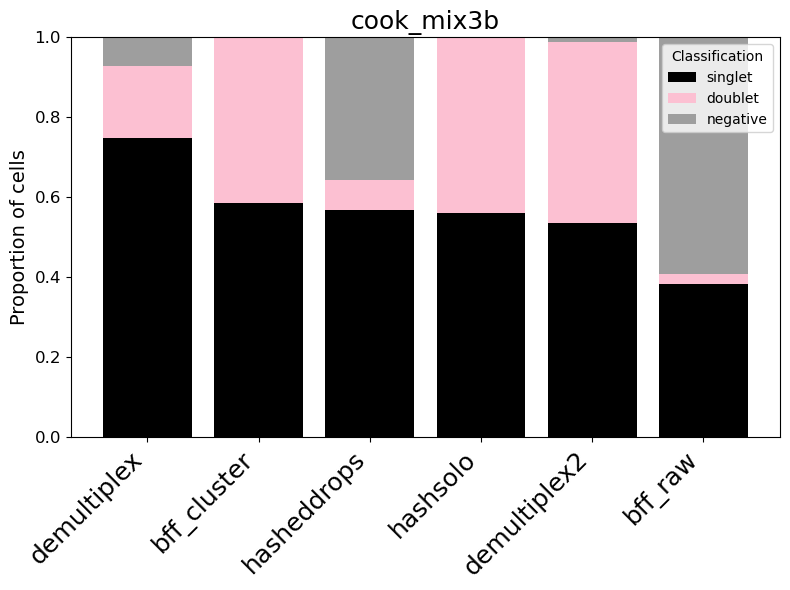

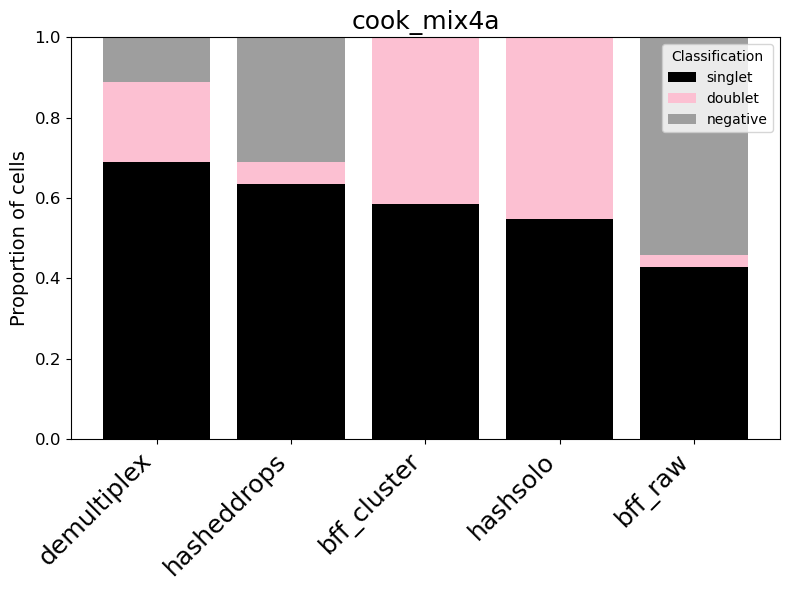

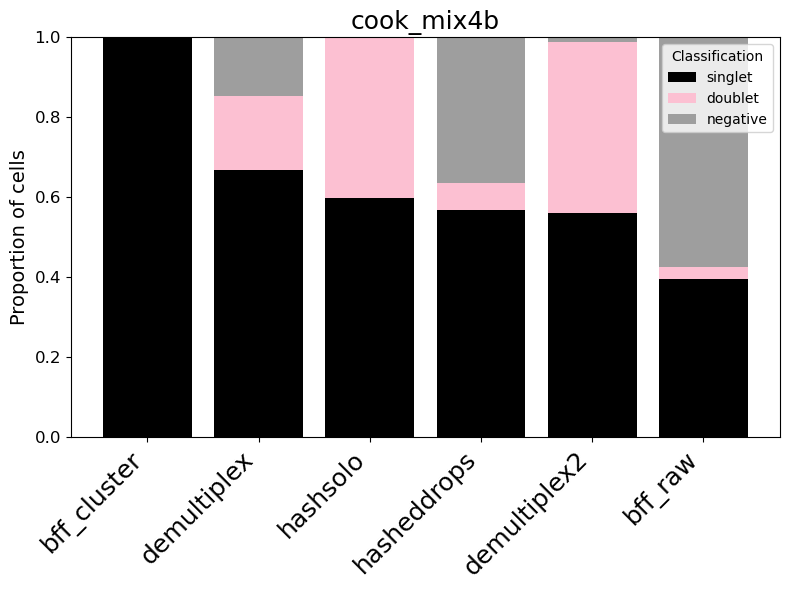

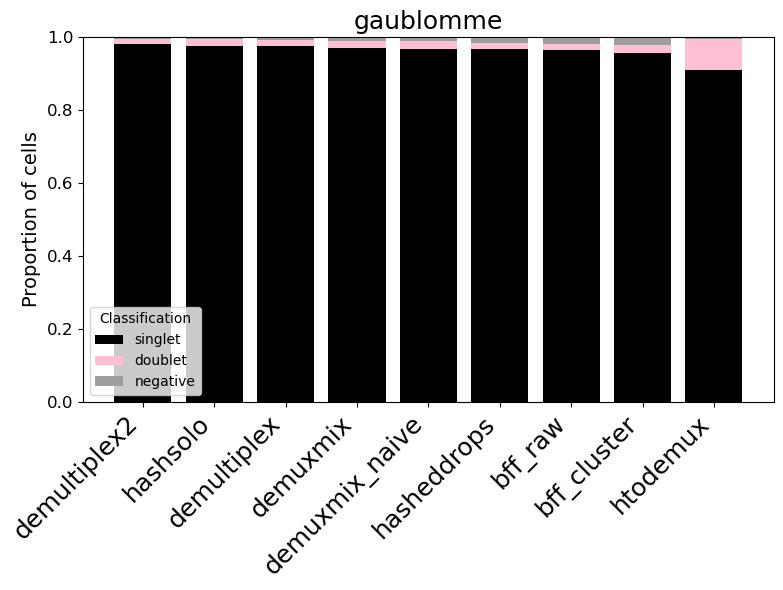

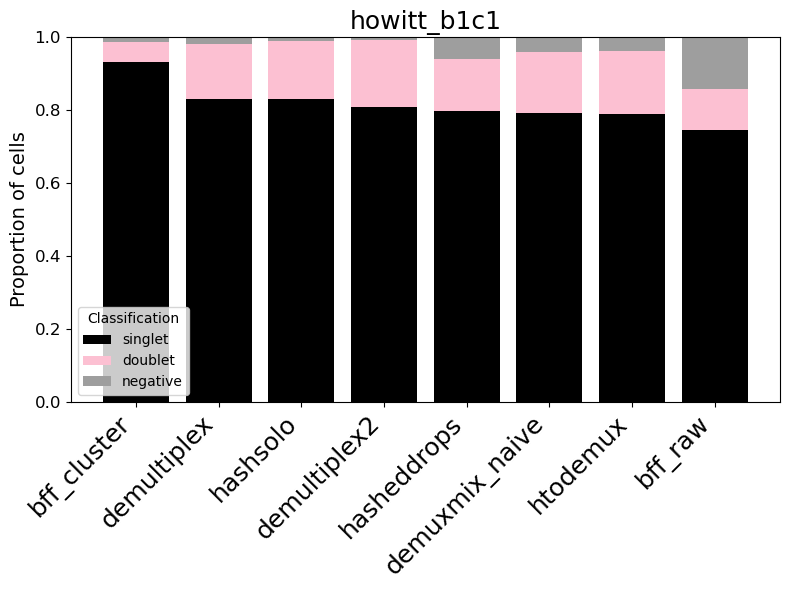

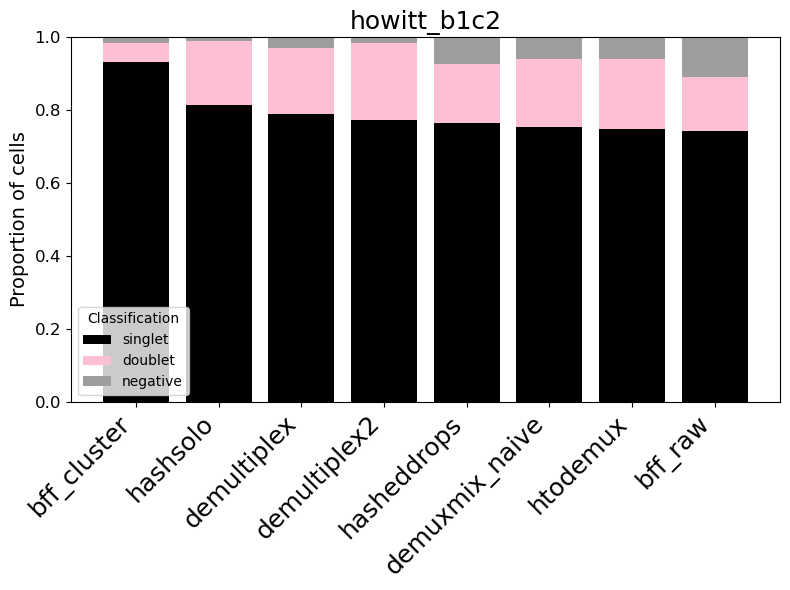

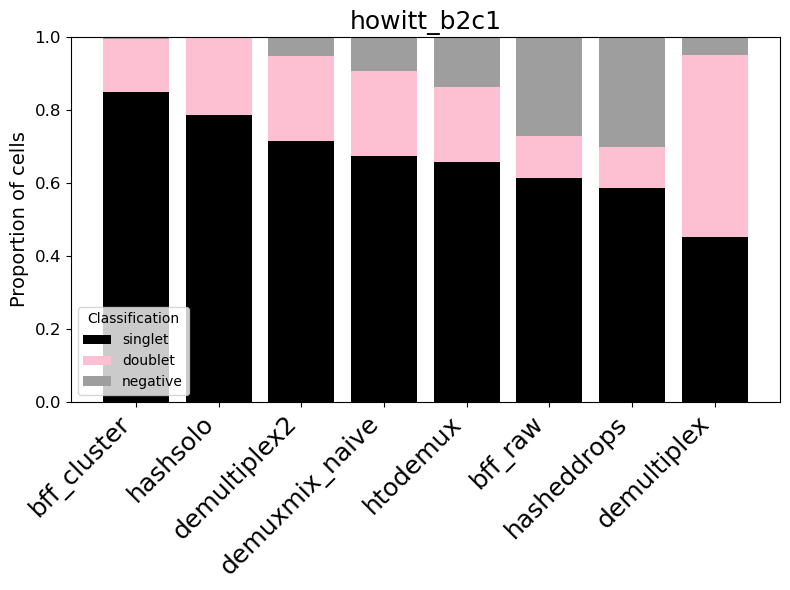

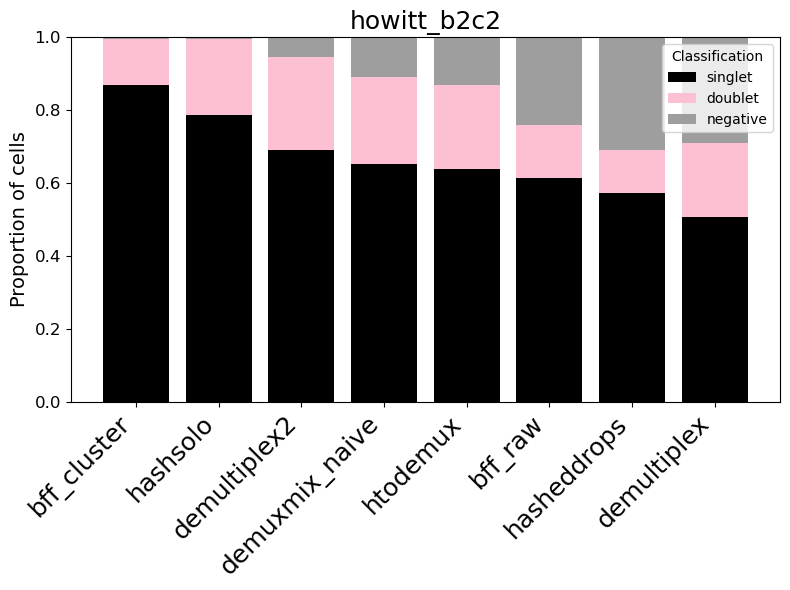

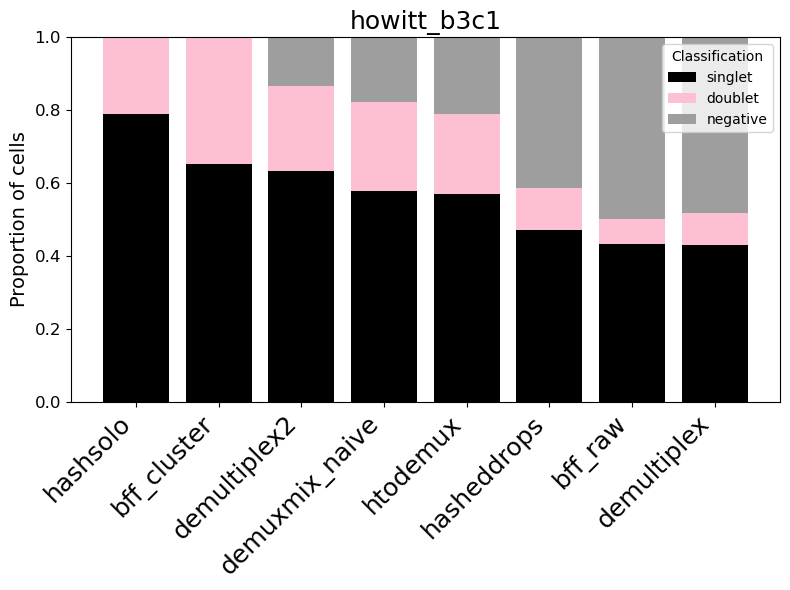

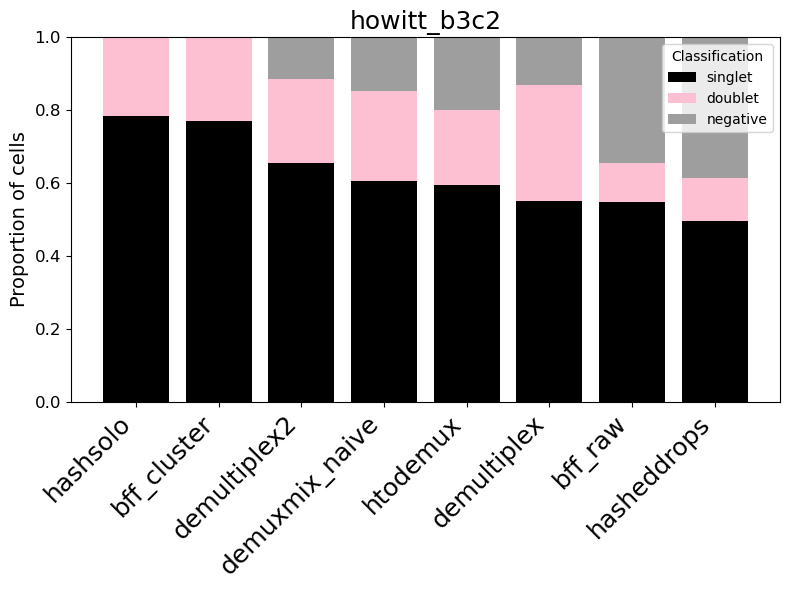

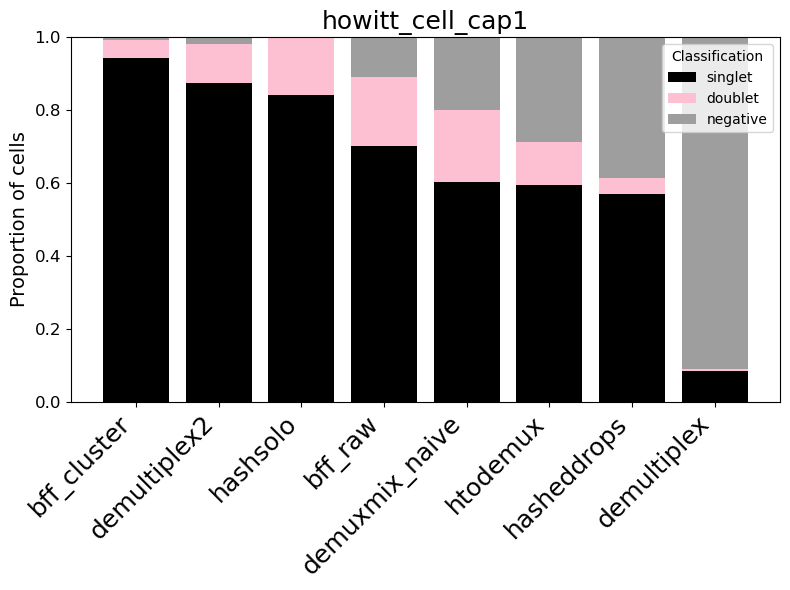

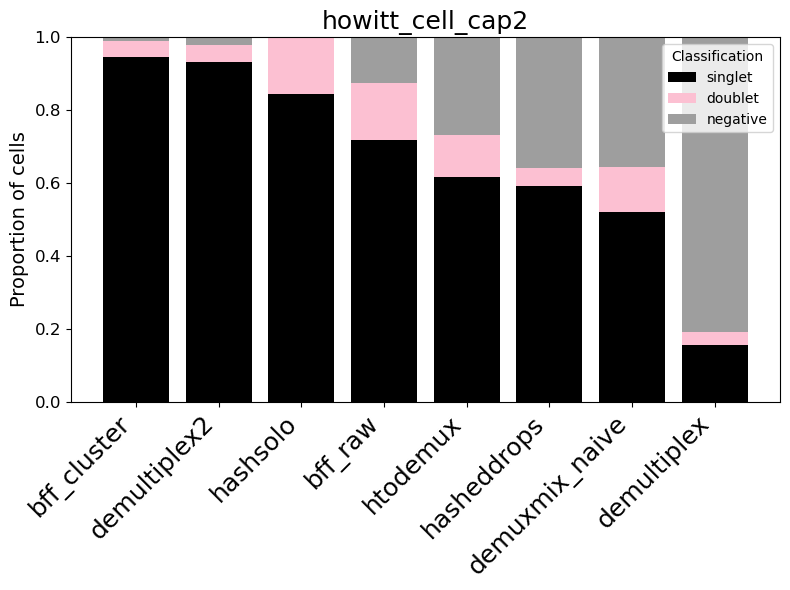

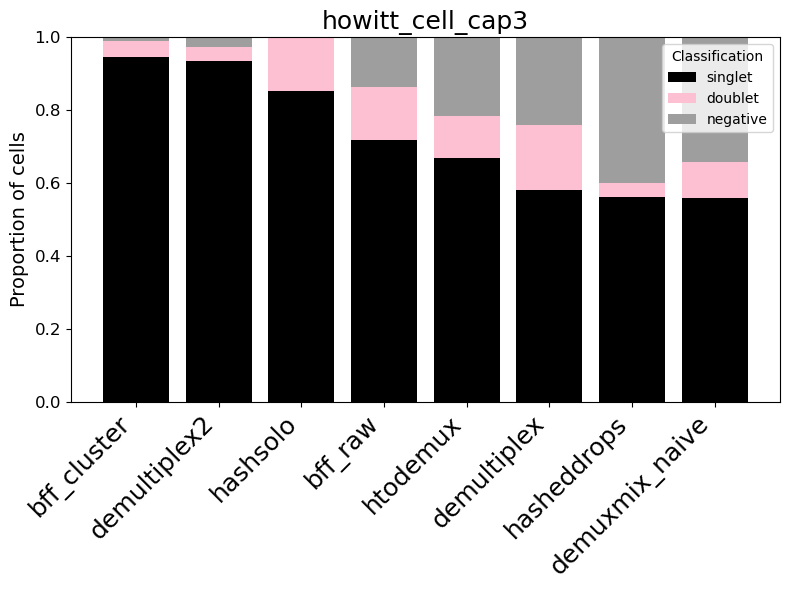

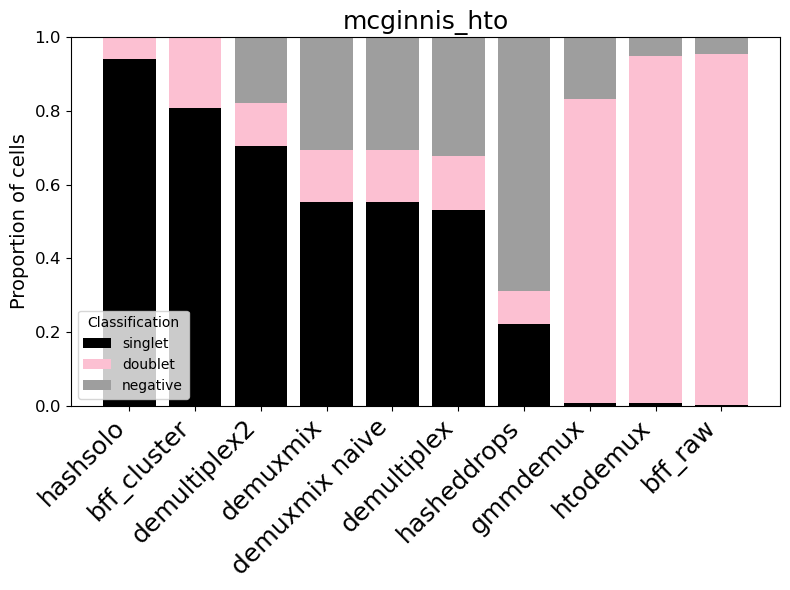

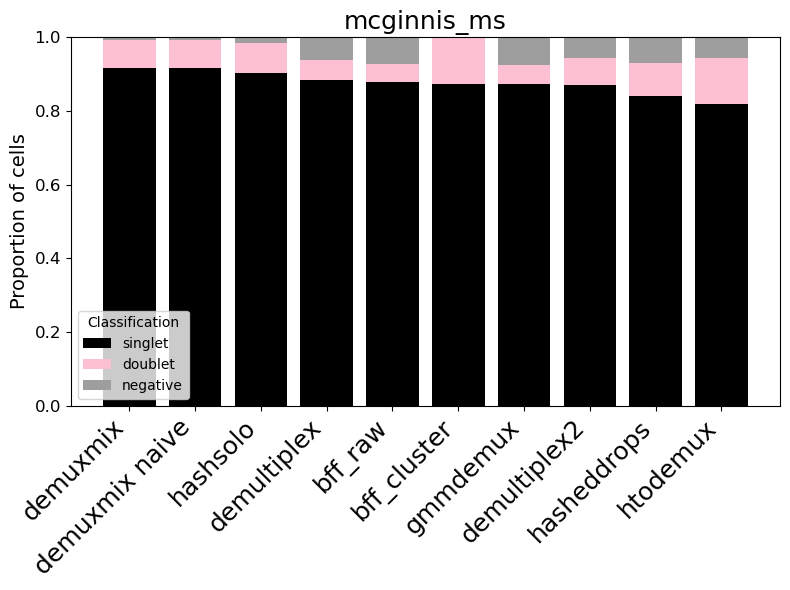

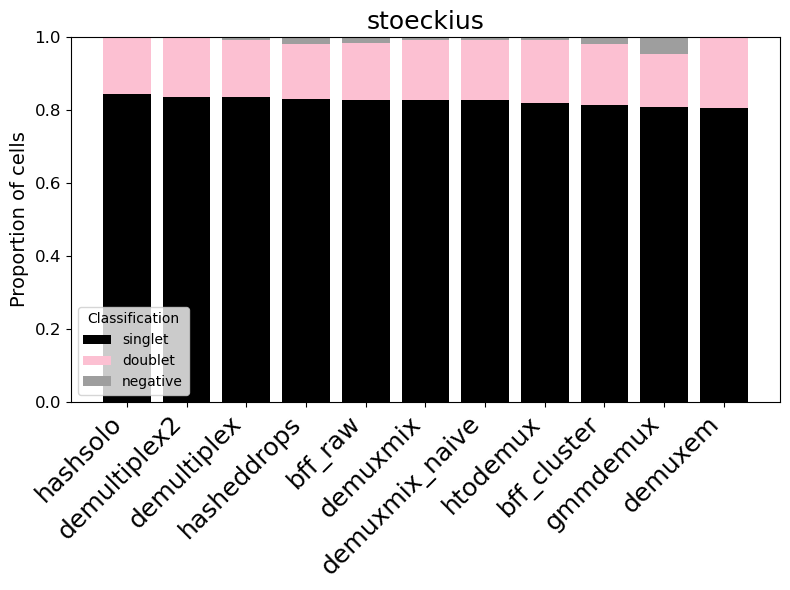

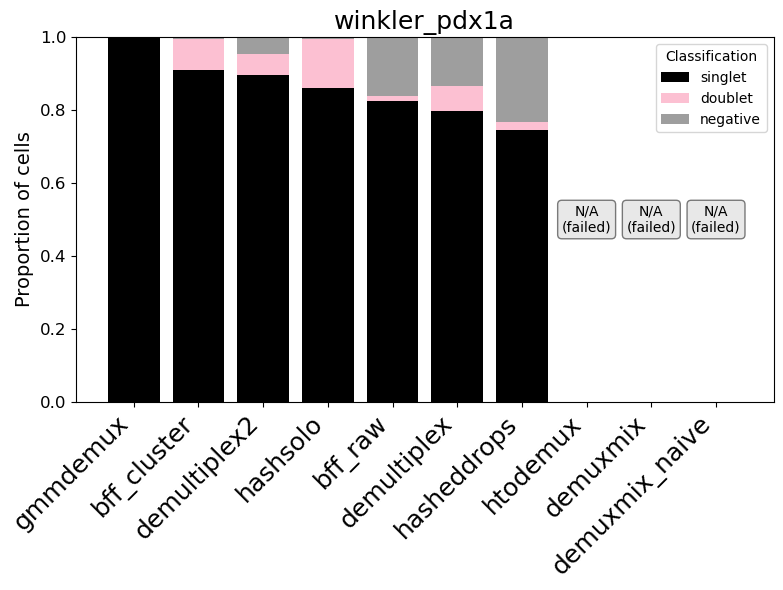

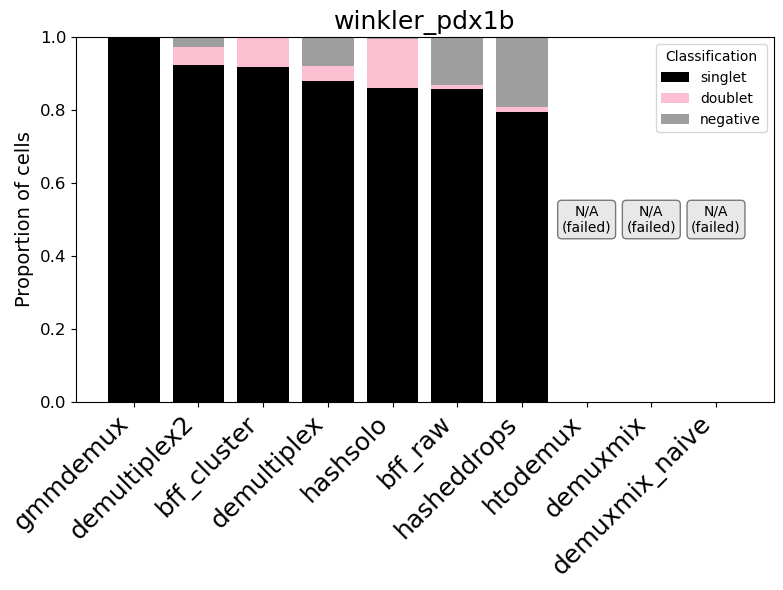

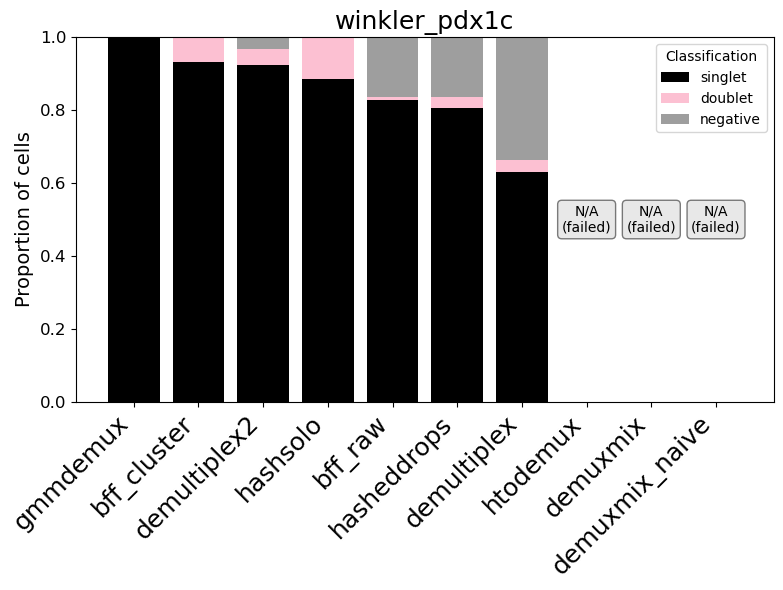

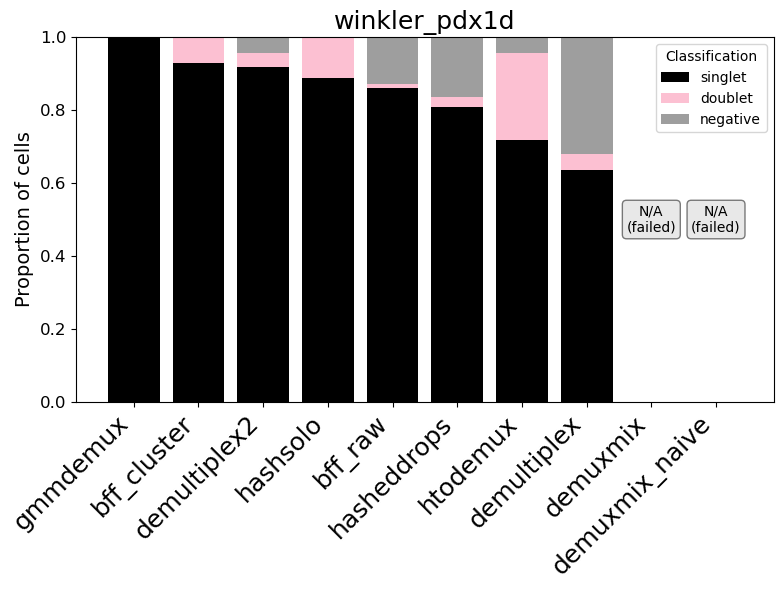

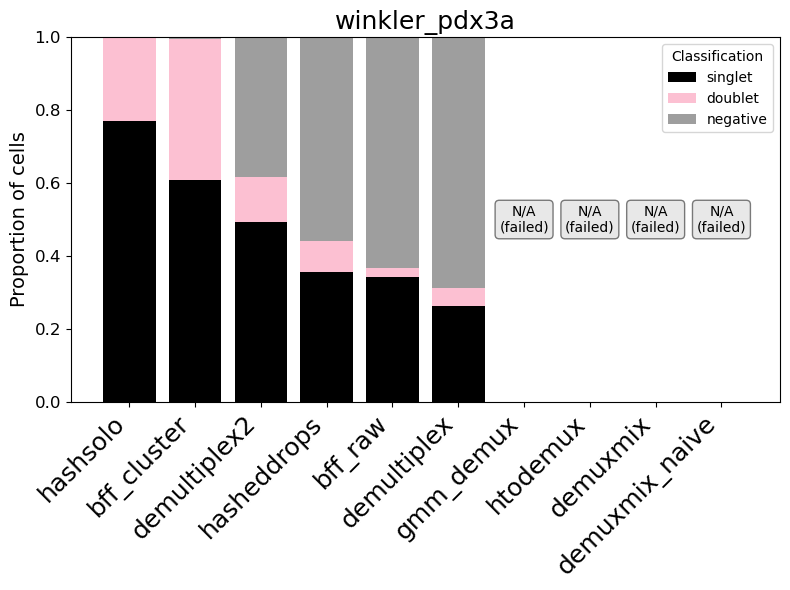

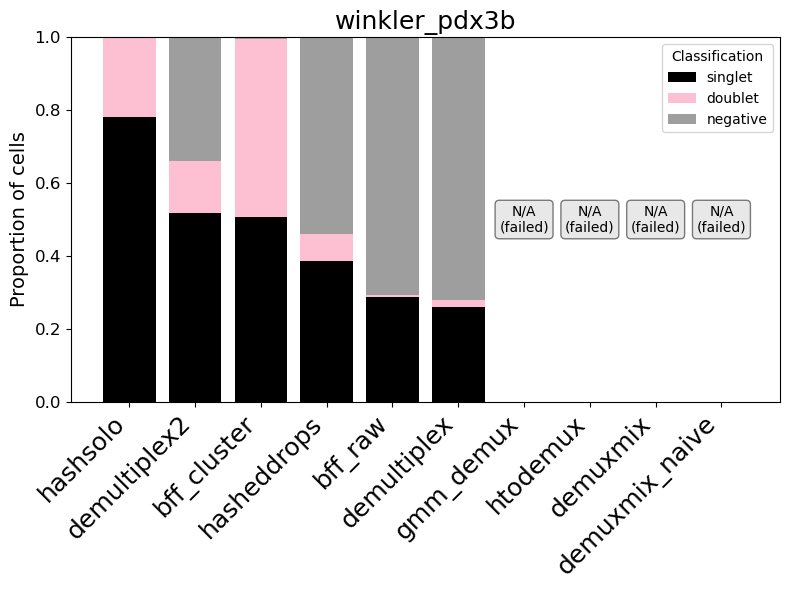

In [56]:
colors = {
    'singlet':  '#000000', 
    'doublet':  '#fcc0d2', 
    'negative': '#9E9E9E'
}

for dataset in datasets:
    dataset_data = plot_data[plot_data['dataset'] == dataset].copy()
    dataset_data['proportion'] = dataset_data.groupby('method')['n'].transform(lambda x: x / x.sum())

    sort_order = dataset_data[dataset_data['classification'] == 'singlet'][['method', 'proportion']].rename(columns={'proportion': 'singlet_prop'})
    sort_order = sort_order.merge(
        dataset_data[dataset_data['classification'] == 'negative'][['method', 'proportion']].rename(columns={'proportion': 'negative_prop'}),
        on='method',
        how='left'
    ).fillna(0)

    # sort by singlet desc 
    sort_order = sort_order.sort_values(['singlet_prop'], ascending=[False])
    method_order = sort_order['method'].tolist()

    pivot = dataset_data.pivot_table(
        index='method',
        columns='classification',
        values='proportion',
        fill_value=0
    )

    # apply order to pivot
    pivot = pivot.loc[method_order]

    errors_for_dataset = errors[errors['dataset'] == dataset]
    for _, row in errors_for_dataset.iterrows():
        if row['method'] not in pivot.index:
            pivot.loc[row['method']] = 0

    col_order = [c for c in ['singlet', 'doublet', 'negative'] if c in pivot.columns]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = pd.Series([0] * len(pivot), index=pivot.index)

    for classification in col_order:
        bars = ax.bar(pivot.index, pivot[classification],
                  bottom=bottom,
                  label=classification,
                  color=colors[classification])
        bottom += pivot[classification]

    # add failed methods note
    dataset_errors = errors[errors['dataset'] == dataset]
    for _, row in errors_for_dataset.iterrows():
        method_idx = list(pivot.index).index(row['method'])
        ax.text(method_idx, 0.5, 'N/A\n(failed)', 
            ha='center', va='center',
            fontsize=10, color='black',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    #ax.set_xlabel('Method', fontsize=14)
    ax.set_ylabel('Proportion of cells', fontsize=14)
    ax.set_title(dataset, fontsize=18)
    ax.set_ylim(0, 1)
    ax.legend(title='Classification')
    plt.xticks(rotation=45, ha='right', fontsize=18)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    os.makedirs(f'analysis/figures/{dataset}', exist_ok=True)
    plt.savefig(f'analysis/figures/{dataset}/stacked_bar.pdf')
    plt.show()